In [1]:
## -- Importar librearias necesarios
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
# --- Cargar dataset ---
df = pd.read_excel("../data/raw/database_non-shows.xlsx")
# df = pd.read_excel("database_non-shows.xlsx")


In [5]:
#--- Mostrar las primeras filas del dataframe ---
print(df.columns.tolist())

['Appointment Type', 'Age', 'Sex', 'Insurance Type', 'Number of Diseases', 'Recent Hospitalization', 'Number of Medications', 'Hour', 'Day', 'Month', 'Creation to Assignment Interval', 'Number of Previous Attendance', 'Number of Previous Non-Attendance']


In [6]:
# --- Vista general ---
df.head()        # primeras 5 filas
df.shape         # dimensiones (filas, columnas)
df.info()        # tipos de datos y nulos
df.describe()    # estadísticas básicas de numéricas

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18587 entries, 0 to 18586
Data columns (total 13 columns):
 #   Column                             Non-Null Count  Dtype
---  ------                             --------------  -----
 0   Appointment Type                   18587 non-null  int64
 1   Age                                18587 non-null  int64
 2   Sex                                18587 non-null  int64
 3   Insurance Type                     18587 non-null  int64
 4   Number of Diseases                 18587 non-null  int64
 5   Recent Hospitalization             18587 non-null  int64
 6   Number of Medications              18587 non-null  int64
 7   Hour                               18587 non-null  int64
 8   Day                                18587 non-null  int64
 9   Month                              18587 non-null  int64
 10  Creation to Assignment Interval    18587 non-null  int64
 11  Number of Previous Attendance      18587 non-null  int64
 12  Number of Previous

,Appointment Type,Age,Sex,Insurance Type,Number of Diseases,Recent Hospitalization,Number of Medications,Hour,Day,Month,Creation to Assignment Interval,Number of Previous Attendance,Number of Previous Non-Attendance
count,18587.000000,18587.000000,18587.000000,18587.000000,18587.000000,18587.000000,18587.000000,18587.000000,18587.000000,18587.000000,18587.000000,18587.000000,18587.000000
mean,0.346156,50.152903,0.380804,2.792167,1.435519,0.037553,0.543229,11.582235,2.790176,6.216926,25.599774,2.680207,2.043794
std,0.475756,17.123270,0.489240,0.891696,1.111154,0.207959,1.232169,2.761017,2.046901,2.773017,28.656826,2.256370,3.431348
min,0.000000,5.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,0.000000,0.000000,-1.000000,0.000000,0.000000
25%,0.000000,37.000000,0.000000,3.000000,1.000000,0.000000,0.000000,9.000000,1.000000,4.000000,8.000000,1.000000,0.000000
50%,0.000000,50.000000,0.000000,3.000000,1.000000,0.000000,0.000000,11.000000,3.000000,7.000000,19.000000,2.000000,1.000000
75%,1.000000,62.000000,1.000000,3.000000,2.000000,0.000000,0.000000,14.000000,4.000000,8.000000,35.000000,4.000000,3.000000
max,1.000000,104.000000,2.000000,8.000000,8.000000,6.000000,18.000000,21.000000,7.000000,12.000000,1673.000000,43.000000,77.000000


In [7]:
#--- Análisis de valores nulos y duplicados ---
df.isnull().sum()
df.duplicated().sum()


np.int64(6)


Matriz de correlación:
                                   Appointment Type       Age       Sex  \
Appointment Type                           1.000000 -0.104079  0.017778   
Age                                       -0.104079  1.000000 -0.024369   
Sex                                        0.017778 -0.024369  1.000000   
Insurance Type                             0.115819  0.032911 -0.006284   
Number of Diseases                        -0.137312  0.220438 -0.003029   
Recent Hospitalization                     0.009997  0.075808  0.008566   
Number of Medications                     -0.131353  0.134860 -0.039358   
Hour                                       0.040628 -0.046051 -0.002631   
Day                                       -0.153760 -0.001733 -0.003378   
Month                                      0.096545  0.059028 -0.002118   
Creation to Assignment Interval           -0.000331  0.102815  0.000398   
Number of Previous Attendance              0.002834  0.204794 -0.014354   
N

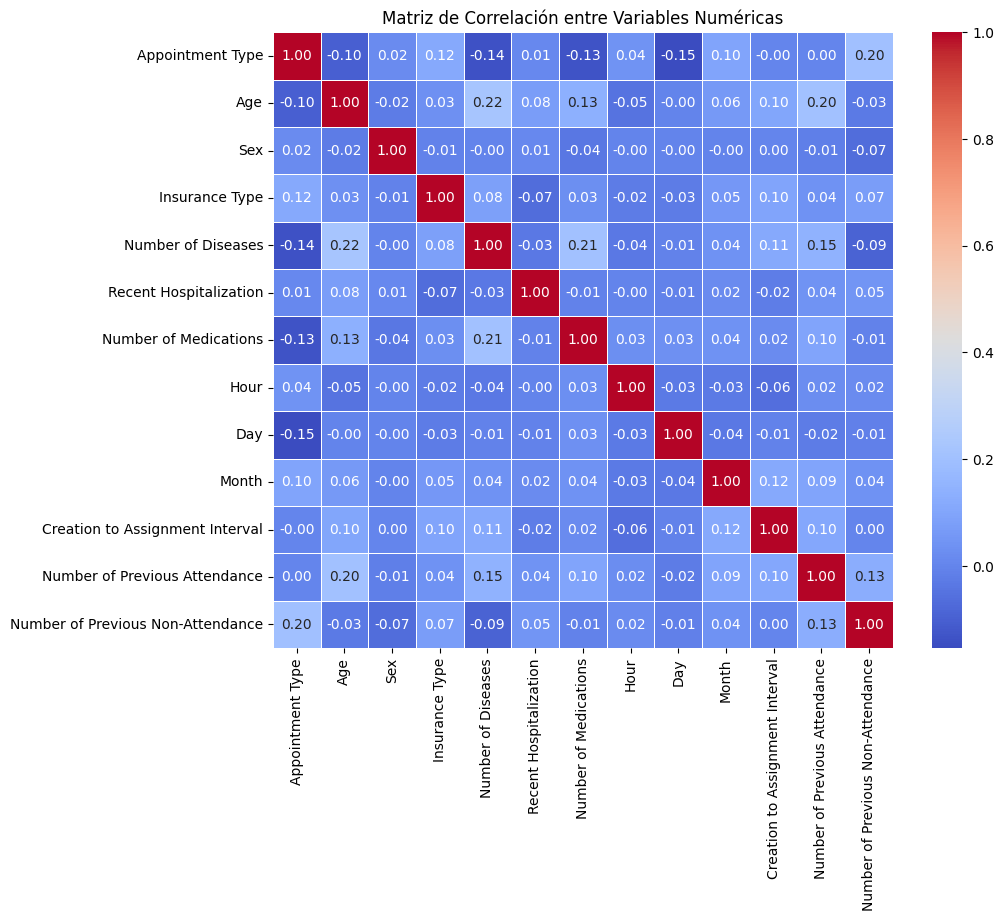

In [9]:
# Calcular la matriz de correlación solo con columnas numéricas
corr_matrix = df.corr(numeric_only=True)

# Mostrar la matriz numérica
print("\nMatriz de correlación:")
print(corr_matrix)

# Visualizarla con un mapa de calor
plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Matriz de Correlación entre Variables Numéricas")
plt.show()

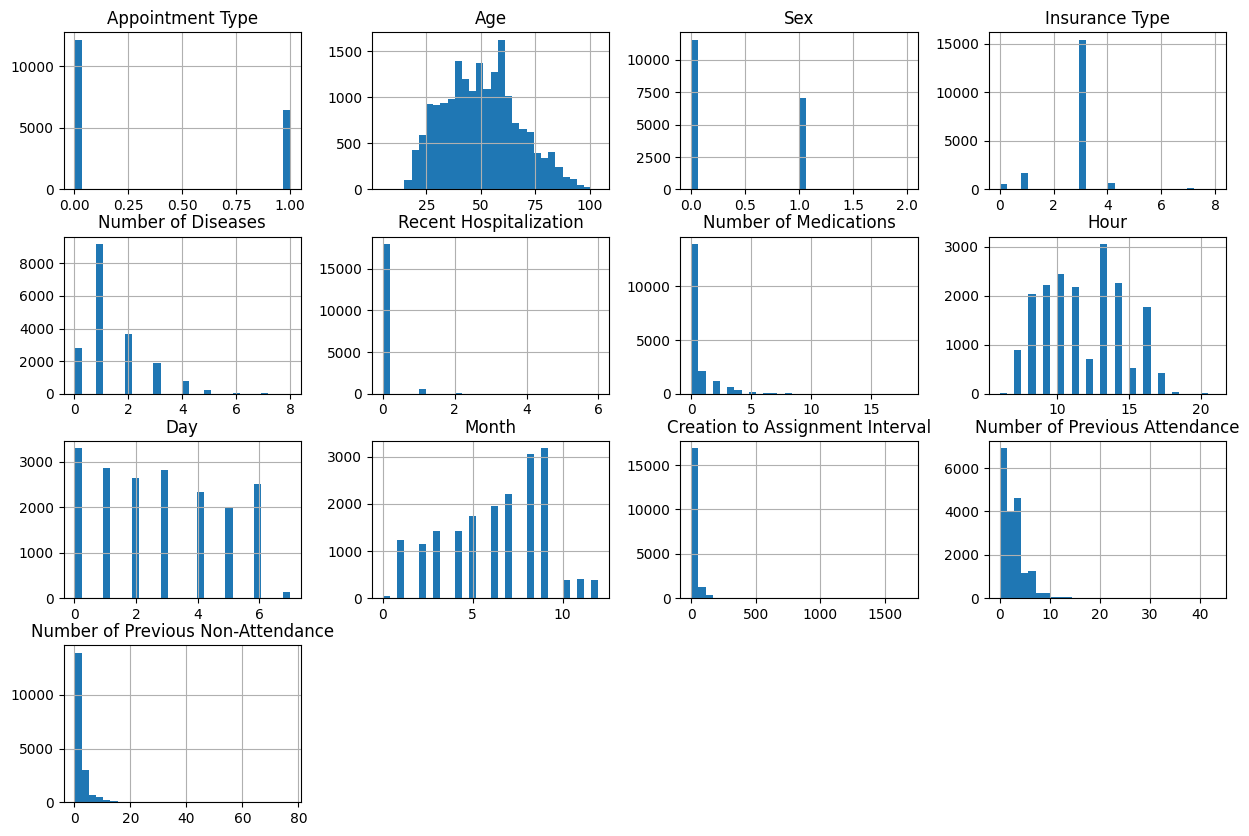

In [8]:
#--- Distribución de variables numéricas ---
df.hist(bins=30, figsize=(15,10))
plt.show()


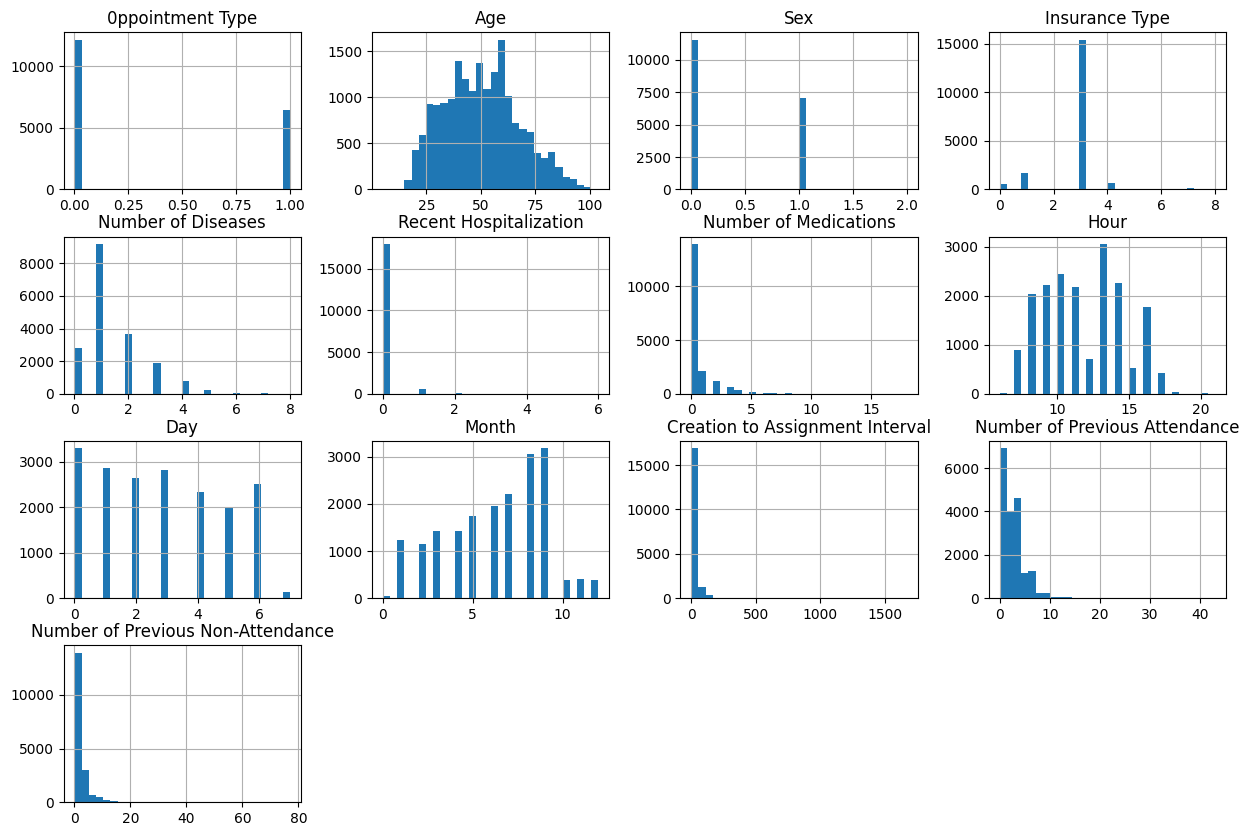

In [ ]:
#--- Distribución de variables numéricas ---
df.hist(bins=30, figsize=(15,10))
plt.show()


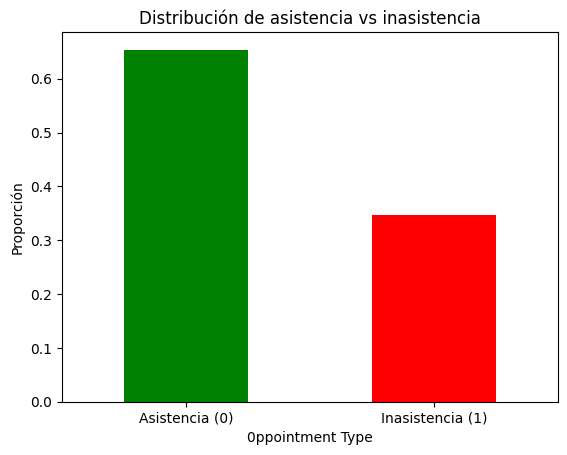

In [ ]:
# Distribución de asistencia vs inasistencia
df['0ppointment Type'].value_counts(normalize=True).plot(
    kind="bar", color=["green", "red"]
)

plt.title("Distribución de asistencia vs inasistencia")
plt.xticks(ticks=[0,1], labels=["Asistencia (0)", "Inasistencia (1)"], rotation=0)
plt.ylabel("Proporción")
plt.show()


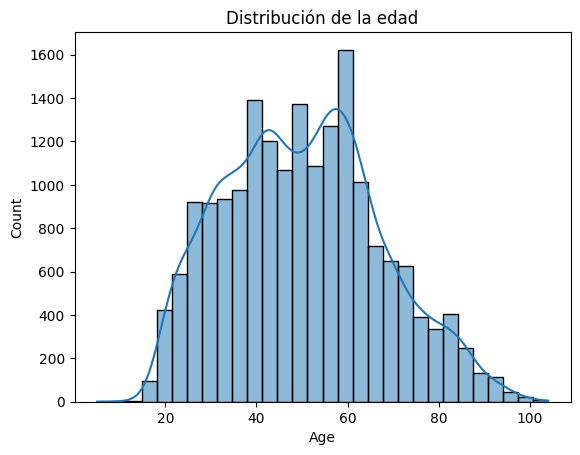

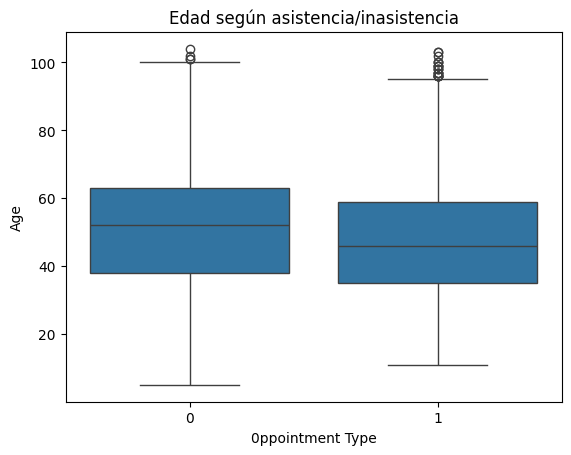

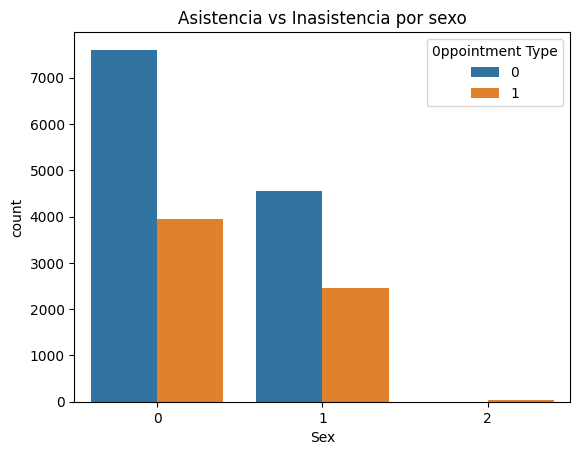

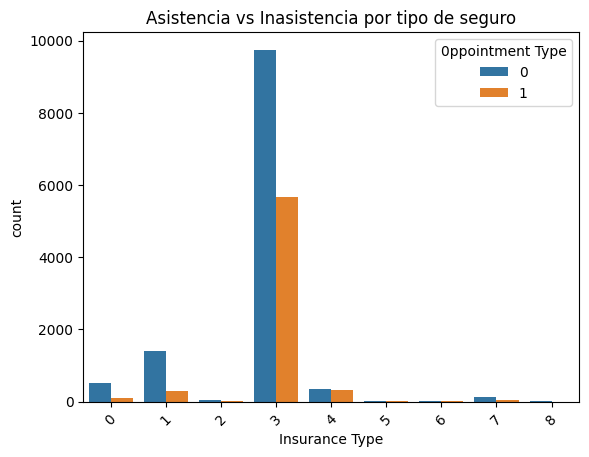

In [ ]:

# ===========================
#  Variables sociodemográficas
# ===========================

# Edad
sns.histplot(df['Age'], bins=30, kde=True)
plt.title("Distribución de la edad")
plt.show()

sns.boxplot(x='0ppointment Type', y='Age', data=df)
plt.title("Edad según asistencia/inasistencia")
plt.show()

# Sexo
sns.countplot(x="Sex", hue="0ppointment Type", data=df)
plt.title("Asistencia vs Inasistencia por sexo")
plt.show()

# Tipo de seguro
sns.countplot(x="Insurance Type", hue="0ppointment Type", data=df)
plt.title("Asistencia vs Inasistencia por tipo de seguro")
plt.xticks(rotation=45)
plt.show()

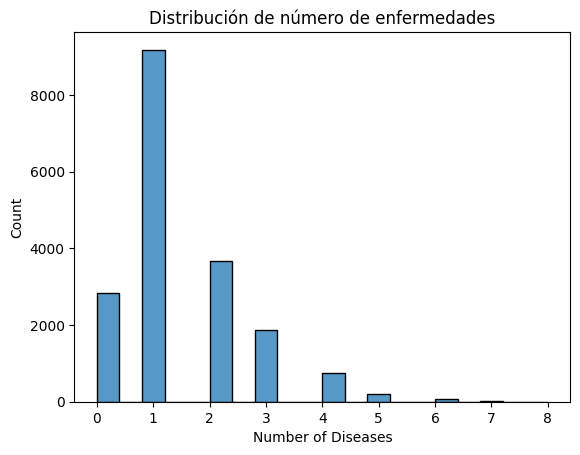

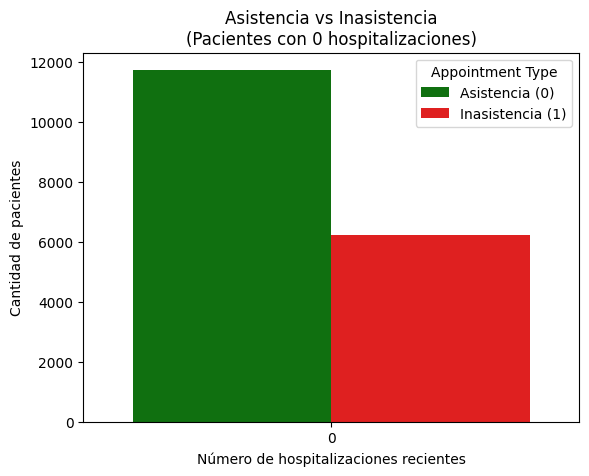

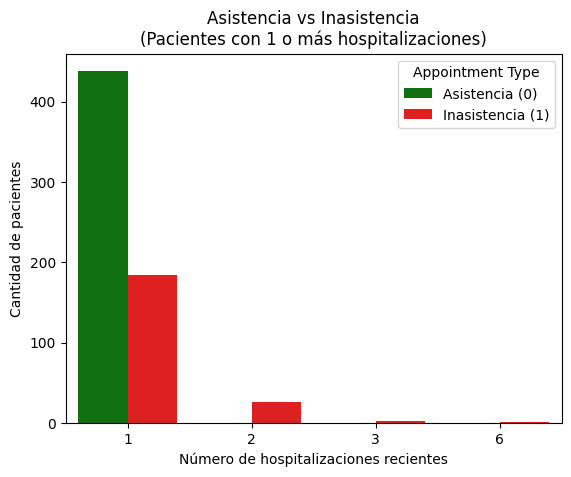

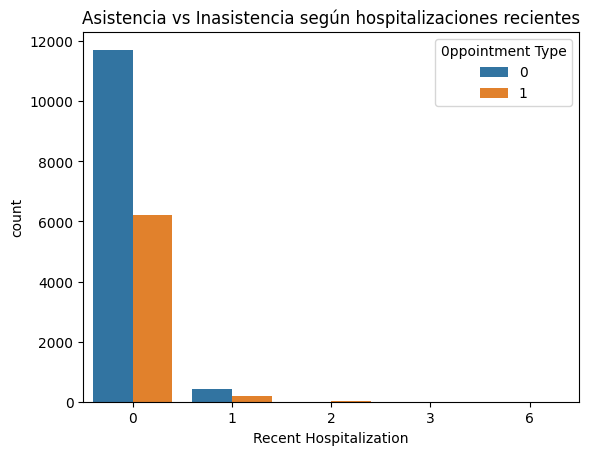

In [ ]:
# ===========================
#  Variables clínicas
# ===========================

# Número de enfermedades
sns.histplot(df['Number of Diseases'], bins=20, kde=False)
plt.title("Distribución de número de enfermedades")
plt.show()

# --- Grupo 1: Pacientes con 0 hospitalizaciones recientes ---
subset_no_hosp = df[df['Recent Hospitalization'] == 0]

sns.countplot(x="Recent Hospitalization", hue="0ppointment Type", data=subset_no_hosp, palette=["green", "red"])
plt.title("Asistencia vs Inasistencia\n(Pacientes con 0 hospitalizaciones)")
plt.xlabel("Número de hospitalizaciones recientes")
plt.ylabel("Cantidad de pacientes")
plt.legend(title="Appointment Type", labels=["Asistencia (0)", "Inasistencia (1)"])
plt.show()

# --- Grupo 2: Pacientes con 1 o más hospitalizaciones recientes ---
subset_hosp = df[df['Recent Hospitalization'] > 0]

sns.countplot(x="Recent Hospitalization", hue="0ppointment Type", data=subset_hosp, palette=["green", "red"])
plt.title("Asistencia vs Inasistencia\n(Pacientes con 1 o más hospitalizaciones)")
plt.xlabel("Número de hospitalizaciones recientes")
plt.ylabel("Cantidad de pacientes")
plt.legend(title="Appointment Type", labels=["Asistencia (0)", "Inasistencia (1)"])
plt.show()


# Hospitalización reciente
sns.countplot(x="Recent Hospitalization", hue="0ppointment Type", data=df)
plt.title("Asistencia vs Inasistencia según hospitalizaciones recientes")
plt.show()



C:\Users\alejo\AppData\Local\Temp\ipykernel_33312\1626566398.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="0ppointment Type", data=subset_no_hosp, palette=["green", "red"])


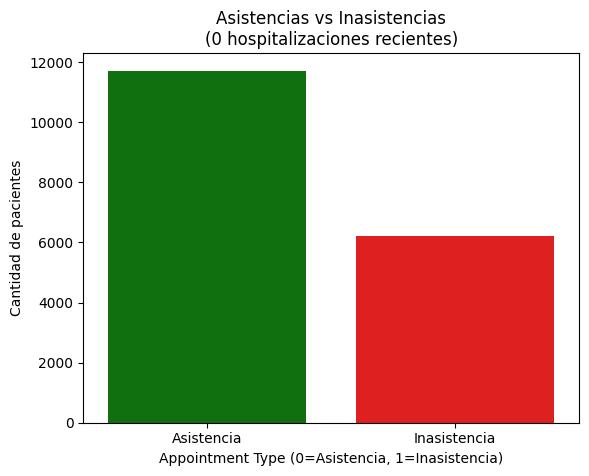

C:\Users\alejo\AppData\Local\Temp\ipykernel_33312\1626566398.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="0ppointment Type", data=subset_hosp, palette=["green", "red"])


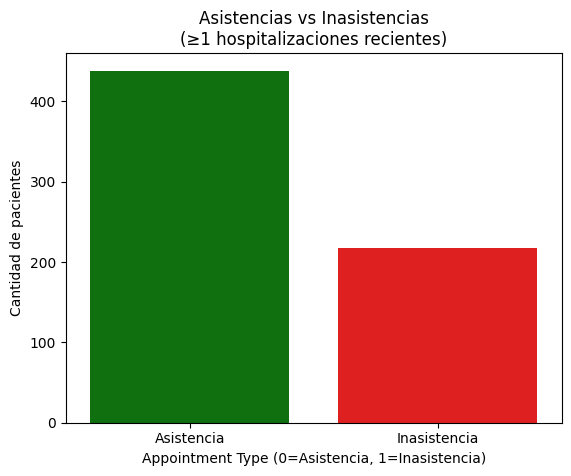

In [ ]:
# --- Grupo 1: Pacientes con 0 hospitalizaciones recientes ---
subset_no_hosp = df[df['Recent Hospitalization'] == 0]

sns.countplot(x="0ppointment Type", data=subset_no_hosp, palette=["green", "red"])
plt.title("Asistencias vs Inasistencias\n(0 hospitalizaciones recientes)")
plt.xlabel("Appointment Type (0=Asistencia, 1=Inasistencia)")
plt.ylabel("Cantidad de pacientes")
plt.xticks([0,1], ["Asistencia", "Inasistencia"])
plt.show()

# --- Grupo 2: Pacientes con 1 o más hospitalizaciones recientes ---
subset_hosp = df[df['Recent Hospitalization'] > 0]

sns.countplot(x="0ppointment Type", data=subset_hosp, palette=["green", "red"])
plt.title("Asistencias vs Inasistencias\n(≥1 hospitalizaciones recientes)")
plt.xlabel("Appointment Type (0=Asistencia, 1=Inasistencia)")
plt.ylabel("Cantidad de pacientes")
plt.xticks([0,1], ["Asistencia", "Inasistencia"])
plt.show()